# 学生队列的辍学时间生存分析

## 执行摘要

**背景。** 一所四年制学院的院校研究办公室希望了解学生*何时*离校，而不仅仅是*是否*离校。一个首次入学队列从注册开始按学期逐期跟踪；有些学生毕业，有些辍学，还有少数在观测窗口关闭时仍在读。由于仍在读学生的结局未知（右删失），并且毕业会使学生在不属于辍学的情况下退出风险人群，普通的通过/失败回归会丢弃时间信息，并使任何忽略删失的估计产生偏差。正确的工具是**事件时间（生存）分析**，其中关注的事件是**辍学**，时钟以已注册的学期数来度量。

**业务问题。** 学生的**首学期学业状态**（一个早期预警标志）是否能区分队列的辍学时间轨迹？在校正之后又是哪些学生特征驱动辍学风险？答案将服务于早期预警系统：估计辍学风险较高的学生应在其最初几个学期获得辅导干预，此时干预成本最低、效果最好。

**方法。** 我们内联模拟一个 100 名学生的队列（无外部数据），然后走完一套标准的生存分析工作流程：

1. **PROC MEANS** 在三种观测结局（毕业 / 辍学 / 仍在读）中对各预测变量做画像，以确认模拟信号表现合理。
2. **PROC FREQ** 将首学期学业状态与结局做交叉列表，并附卡方关联性检验。
3. **PROC UNIVARIATE** 按学业状态报告辍学时间的稳健百分位数。
4. **PROC LIFETEST** 按学业状态分层估计 Kaplan-Meier 辍学曲线，并运行 **log-rank** 与 **Wilcoxon** 同质性检验。
5. **PROC PHREG** 为辍学风险拟合多变量 **Cox 比例风险** 模型，使用参照编码的 `CLASS` 效应、Efron 结值处理以及风险限置信区间。

**数据显示了什么。** 在 100 名模拟学生中，在第 12 学期截尾时**49 人辍学、49 人毕业、2 人仍在读**。首学期被标记为**学业警告**（首学期 GPA 低于 2.5）的学生辍学速度远快于状态良好的学生：辍学中位时间为**3.8 学期对 8.7 学期**，这一区分被 log-rank 检验所证实（卡方 = 10.73，*p* = 0.0011）。Cox 模型识别出首学期 GPA（每提高一个 GPA 点风险比 0.21，*p* < 0.0001）、高中 GPA（HR 0.45，*p* = 0.027）以及第一代大学生身份（HR 2.03，*p* = 0.031）是辍学的显著校正驱动因素，而在控制 GPA 之后 Pell 助学金身份并不显著（HR 0.95，*p* = 0.85）。

> *所有数据均为示意性的，由合成数据生成；它们不是真实的学生记录。本环境以无许可方式运行，因此队列规模设定为 100 名学生。*

## 数据来源

所有数据均为**合成数据**，在第一个 DATA 步中通过 `CALL STREAMINIT(20260611)` 与 `RAND` 函数内联生成。无外部文件或网络访问。每名模拟学生占一行。

**数据集 `入学记录`**（100 行，每名学生一行）

| 变量 | 类型 | 描述 | 生成分布 |
|----------|------|-------------|--------------------------|
| `学生编号` | 数值 | 唯一学生键 | 序列 1–100 |
| `首代标志` / `首代类别` | 数值 / 字符 | 第一代大学生标志（0/1）及其标签 | 伯努利，约 42% |
| `佩尔助学金` | 数值 | Pell 助学金（经济需求）标志（0/1） | 伯努利，约 42% |
| `专业` | 字符 | STEM / BUS / HUM | 分类（约 42% / 32% / 26%） |
| `高中GPA` | 数值 | 高中 GPA（1.8–4.0） | Normal(3.00, 0.42)，截断 |
| `首学期GPA` | 数值 | 首学期大学 GPA（0–4.0） | f(hs_gpa, program) + Normal 噪声 |
| `学业状态` | 字符 | 首学期学业状态 | `首学期GPA < 2.5` → 学业警告，否则状态良好 |
| `学期时长` | 数值 | 直到事件或删失的已注册学期数 | 竞争性 Weibull 抽样；上限为 12 |
| `辍学标志` | 数值 | 辍学事件指示（1 = 辍学，0 = 删失） | 派生 |
| `结局` | 字符 | 毕业 / 辍学 / 在读 | 由竞争性抽样派生 |

一个对数尺度上的潜在线性预测子将每名学生的**辍学率**与首学期 GPA、高中 GPA、第一代大学生身份及经济需求相联系，因此这些预测变量携带真实但含噪声的信号。辍学与毕业被抽取为**竞争性**的潜在时间（Weibull）；在 12 学期窗口内先发生者成为观测结局，而到达第 12 学期两者均未发生的学生被右删失。对于生存模型，**事件为辍学**（`辍学标志 = 1`）；毕业与继续在读均按删失处理（`辍学标志 = 0`）。

## 1. 模拟学生队列

第一个单元构建一个 100 名学生的合成队列。一个对数尺度上的潜在线性预测子将每名学生的辍学率与首学期 GPA、高中 GPA、第一代大学生身份及 Pell 身份相联系。辍学与毕业被生成为**竞争性**的潜在时间（Weibull 抽样）；在 12 学期观测窗口内先发生者成为观测结局，而到达第 12 学期既未辍学也未毕业的学生被右删失。首学期 GPA 低于 2.5 会将学生标记为**学业警告**——即我们在生存分析步骤中检验的早期预警信号。随机抽样使用 `CALL STREAMINIT` 以保证可复现，并跨 Uniform、Normal 和 Weibull 分布使用 `RAND` 函数。硬性下限和截断保持每个取值合理（GPA 在 0–4.0）。

In [1]:
数据 入学记录;
    调用 streaminit(20260611);
    长度 学业状态 $24 首代类别 $24 专业 $12 结局 $12;
    循环 学生编号 = 1 到 100;
        /* 第一代大学生与经济需求标志 */
        首代标志 = (rand("uniform") < 0.42);
        如果 首代标志 那么 首代类别 = "第一代大学生";
        否则              首代类别 = "持续代";
        佩尔助学金 = (rand("uniform") < 0.42);

        /* 就读专业 */
        v = rand("uniform");
        如果      v < 0.42 那么 专业 = "STEM";
        否则 如果 v < 0.74 那么 专业 = "BUS";
        否则                  专业 = "HUM";

        /* 学业准备度与首学期表现 */
        高中GPA = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        首学期GPA = round(MIN(4.0, MAX(0.0,
                     0.55*高中GPA + 1.05 + 0.12*(专业="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* 早期预警标志：首学期 GPA 低于 2.5 = 学业警告 */
        如果 首学期GPA < 2.5 那么 学业状态 = "学业警告";
        否则                    学业状态 = "状态良好";

        /* 对数尺度上的潜在辍学风险：较低 GPA、第一代
           大学生身份与 Pell 身份会抬高辍学率。 */
        eta = -1.05
             - 1.45*(首学期GPA - 2.8)
             - 0.55*(高中GPA - 3.0)
             + 1.05*首代标志
             + 0.45*佩尔助学金;
        drop_rate = EXP(eta);

        /* 竞争性潜在时间（学期）：辍学 vs 毕业 */
        t_drop = rand("weibull", 1.2, 7.0) / MAX(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(首学期GPA - 2.8));

        /* 12 学期的行政删失窗口 */
        censor_at = 12;
        如果 t_drop <= t_grad 并且 t_drop <= censor_at 那么 循环;
            结局 = "辍学";   辍学标志 = 1; 学期时长 = t_drop;
        结束;
        否则 如果 t_grad < t_drop 并且 t_grad <= censor_at 那么 循环;
            结局 = "毕业"; 辍学标志 = 0; 学期时长 = t_grad;
        结束;
        否则 循环;
            结局 = "在读";  辍学标志 = 0; 学期时长 = censor_at;
        结束;
        学期时长 = round(学期时长, 0.1);
        输出;
    结束;
    保留 学生编号 首代标志 首代类别 佩尔助学金 专业 高中GPA
         首学期GPA 学业状态 学期时长 辍学标志 结局;
运行;



NOTE: DATA 入学记录


NOTE: Wrote 入学记录 (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 按观测结局对预测变量做画像

在建模之前，我们确认模拟的预测变量朝预期方向变化。**PROC MEANS** 在三种观测结局内报告每个数值预测变量的计数、均值、离散度和范围。

队列分为**49 毕业 / 49 辍学 / 2 仍在读**。毕业生具有更高的首学期 GPA（均值 **2.94** 对辍学学生的 **2.54**）以及更高的高中 GPA（**3.10** 对 **2.90**）——正是分析所预期的学业准备度梯度。两名仍在读学生的 `学期时长` 恰好位于 12 学期删失上限（均值 12.00，标准差 0），这正是流失分析必须尊重的右删失。在辍学学生中，事件到来得很早：均值 **3.31 学期**，范围从 0.1 到 8.9。

In [2]:
过程 均值 数据=入学记录 n mean std MIN MAX maxdec=2;
    分类 结局;
    变量 高中GPA 首学期GPA 学期时长;
    标签 高中GPA="高中平均绩点"
          首学期GPA="首学期平均绩点"
          学期时长="至事件学期数";
运行;


                                                  The MEANS Procedure

                                    Analysis Variable : 高中GPA 高中平均绩点

        结局                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        在读                    2           3.10           0.17           2.98           3.22
        毕业                   49           3.10           0.46           1.97           4.00
        辍学                   49           2.90           0.45           2.01           3.89
        -----------------------------------------------------------------------------------

                                 Analysis Variable : 首学期GPA 首学期平均绩点

        结局                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        在读                    2           2.75       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 早期预警标志能否追踪结局？

早期预警系统会将任何首学期 GPA 低于 2.5 的学生标记为**学业警告**。**PROC FREQ** 将该标志与观测结局做交叉列表，并运行卡方关联性检验。我们抑制行、列和总体百分比（`NOROW NOCOL NOPERCENT`），使表格显示原始计数，并加入 `学业状态` 与第一代大学生身份的单向频数以呈现队列构成。

交叉表非常鲜明：在被标记为学业警告的**29** 名学生中，**21 人辍学**，仅 8 人毕业；在**71** 名状态良好的学生中，**41 人毕业**，28 人辍学。该关联显著（卡方 = 9.21，df = 2，*p* = 0.0100；Cramer's V = 0.30）。请注意**随之打印的警告**：在 100 名学生且只有两名毕业生的稀薄“在读”列的情况下，表格中三分之一的单元格期望计数低于 5，因此这里的卡方 *p* 值很脆弱。这种脆弱性正是下一节的生存检验——使用完整时间信息而非 3×2 表格——成为对学业状态效应更可信检验的原因。

                                                   The FREQ Procedure

Table of 学业状态 by 结局

学业状态         |        在读 |        毕业 |        辍学 |      Total
-------------+-----------+-----------+-----------+-----------
学业警告         |         0 |         8 |        21 |         29
-------------+-----------+-----------+-----------+-----------
状态良好         |         2 |        41 |        28 |         71
-------------+-----------+-----------+-----------+-----------
Total        |         2 |        49 |        49 |        100

Statistics for Table of 学业状态 by 结局

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2904


                                          Cumulative    Cumulative
学业状态            Frequenc


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_学业状态_结局.spec.json
NOTE: ODS plot written: freq_学业状态.spec.json
NOTE: ODS plot written: freq_首代类别.spec.json
NOTE: PROC FREQ statement used.


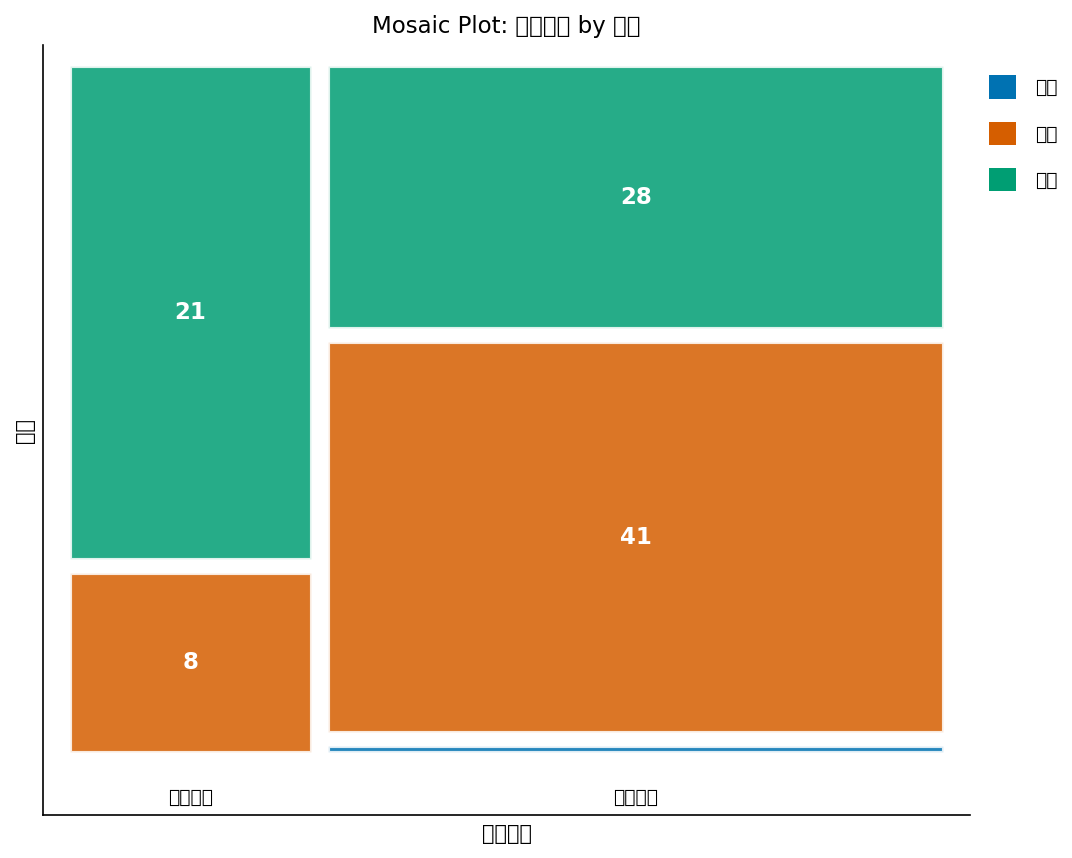

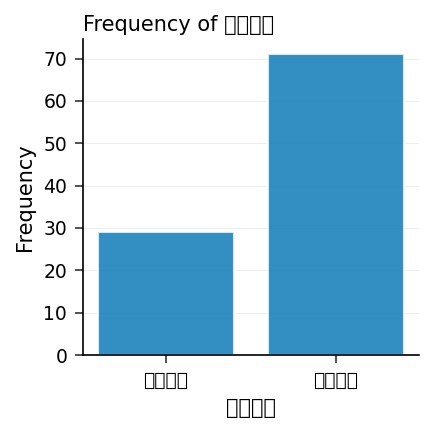

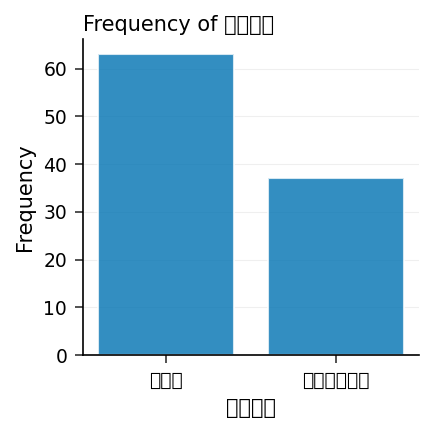

In [3]:
过程 频率 数据=入学记录;
    TABLES 学业状态*结局 / chisq norow nocol nopercent;
    TABLES 学业状态 首代类别;
运行;


## 4. 辍学何时发生？按学业状态的百分位数

对于真正辍学的学生，他们*何时*离校？**PROC UNIVARIATE**（限定于 `辍学标志 = 1`）报告每个学业状态组内辍学时间的第 10、第 50（中位数）和第 90 百分位数，写入一个输出数据集，随后我们将其打印。这在不假设分布的情况下描述辍学时间的离散度。

在辍学学生中，辍学中位时间约为第 **2.4** 学期（学业警告）对 **2.6** 学期（状态良好）——非常接近，因为*在辍学的条件下*，两组都倾向于早离校。因此，学业状态效应主要不在于辍学*何时*发生，而在于*有多少*学生辍学以及风险人群变薄的速度，这正是下一节 Kaplan-Meier 曲线所捕捉的。

In [4]:
过程 UNIVARIATE 数据=入学记录 NOPRINT;
    条件 辍学标志 = 1;
    分类 学业状态;
    变量 学期时长;
    输出 out=辍学参考 pctlpts=10 50 90 pctlpre=分位 p=;
运行;

过程 打印 数据=辍学参考 noobs 标签;
    标题 "各学业状态的辍学时间百分位数（学期）";
运行;
标题;


                                                   各学业状态的辍学时间百分位数（学期）                                                   

        学业状态      分位10      分位50      分位90
学业警告               0.2       2.4       7.9
状态良好               0.4       2.6       8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset 辍学参考 has 2 observations and 4 variables.
NOTE: PROC PRINT data=辍学参考

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. 按学业状态的 Kaplan-Meier 辍学曲线

现在进入核心的生存分析步骤。**PROC LIFETEST** 估计*辍学时间*的非参数 **Kaplan-Meier** 生存函数，将毕业和继续在读视为删失（`辍学标志(0)` 标记删失观测）。按 `学业状态` 分层为每组生成一条辍学曲线，`TEST=(LOGRANK WILCOXON)` 运行两种互补的检验来判断这些曲线是否不同：**log-rank** 检验对所有事件时间等权重（对晚期差异敏感），而 **Wilcoxon** 检验对早期事件时间加权更大（对早期流失敏感）。`PLOTS=SURVIVAL` 请求叠加的生存曲线图形。

在整个队列中共有**49 个辍学事件和 51 个删失**观测。曲线明显分离：处于学业警告的学生达到**生存（辍学时间）中位数 3.8 学期**，而状态良好的学生持续时间超过两倍（**8.7 学期**）。两项检验均拒绝相等——**log-rank 卡方 = 10.73，*p* = 0.0011；Wilcoxon 卡方 = 7.66，*p* = 0.0056**——且可比的统计量告诉我们这一差距在整个注册窗口中持续存在，而非仅是早期的骤增。图形使信息一目了然：橙色的学业警告曲线在前四个学期陡然下降，而蓝色的状态良好曲线保持高位。

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: 学业状态 = 学业警告

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804              22              


NOTE: PROC LIFETEST data=入学记录

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


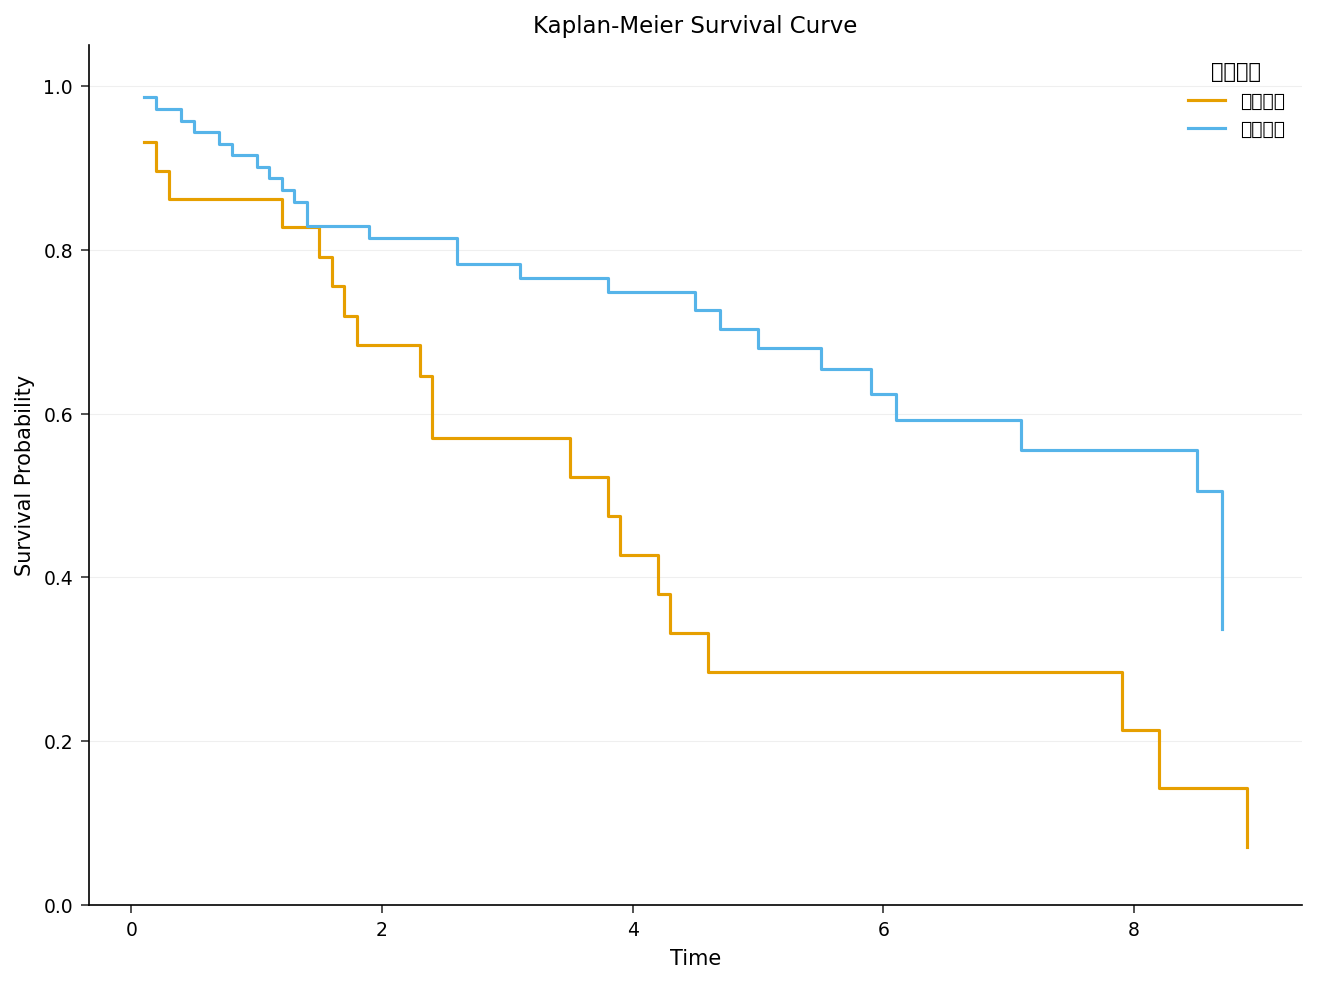

In [5]:
过程 LIFETEST 数据=入学记录 PLOTS=SURVIVAL METHOD=km;
    TIME 学期时长*辍学标志(0);
    STRATA 学业状态 / TEST=(logrank WILCOXON);
运行;


## 6. 辍学的多变量 Cox 比例风险模型

**PROC PHREG** 为辍学风险拟合 **Cox 比例风险** 模型，同时校正各预测变量。关键请求：

- `辍学标志(0)` 使**辍学**成为事件，其余一切为删失。
- `CLASS 首代类别 (ref="持续代") / param=ref` 对第一代大学生因子做参照编码，使其风险比相对于持续代（非第一代）学生来解读。
- `TIES=EFRON` 是当多名学生在同一学期离校时推荐的结值处理近似。
- `RL` 添加风险比（风险限）置信区间。
- `HAZARDRATIO` 语句报告第一代大学生相对于参照组的对比。

风险比大于 1 表示辍学*更快*（风险更高）；小于 1 表示辍学*更慢*（保护性）。

In [6]:
过程 PHREG 数据=入学记录;
    分类 首代类别 (REF="持续代") / PARAM=REF;
    模型 学期时长*辍学标志(0) = 高中GPA 首学期GPA 首代类别 佩尔助学金
          / TIES=efron rl;
    hazardratio "第一代 vs 持续代" 首代类别 / DIFF=REF;
运行;


        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                              Analysis of Maximum Likelihood Estimates                                               

Parameter                              DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------


NOTE: PROC PHREG data=入学记录

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. 解读与后续步骤

**从头到尾解读输出：**

- **PROC MEANS** 确认了模拟信号：毕业学生的首学期 GPA（2.94 对 2.54）和高中 GPA（3.10 对 2.90）高于辍学学生，且仍在读学生位于 12 学期上限——这正是生存模型所尊重的右删失。
- **PROC FREQ** 显示首学期学业警告标志追踪结局（29 名被标记学生中 21 人辍学；71 名状态良好学生中 41 人毕业；*p* = 0.0100），同时诚实地指出在单元格稀疏的 100 名学生表格中卡方是脆弱的。
- **PROC UNIVARIATE** 显示*在辍学的条件下*，两组都早离校（中位数约 2.4–2.6 学期）；学业状态效应关乎有多少学生辍学以及风险人群变薄的速度，而非离校者之间的时间差异。
- **PROC LIFETEST** 给出了核心结论：按学业状态明显分离的 Kaplan-Meier 辍学曲线（中位数 3.8 对 8.7 学期；log-rank *p* = 0.0011，Wilcoxon *p* = 0.0056）。早期预警标志是辍学时间的真实、有统计支持的判别指标。
- **PROC PHREG** 量化了每个预测变量对辍学风险的校正效应。校正之后，**首学期 GPA 是最强的保护因素**（每 GPA 点风险比 0.21，95% CI 0.10–0.44，*p* < 0.0001）：每增加一个 GPA 点使辍学风险降低约五分之四。**高中 GPA** 也具保护性（HR 0.45，95% CI 0.22–0.91，*p* = 0.027）。**第一代大学生**面临的辍学风险约为具有相同 GPA 的持续代同龄人的两倍（HR 2.03，95% CI 1.07–3.84，*p* = 0.031）。**在控制 GPA 之后 Pell 身份并不显著**（HR 0.95，95% CI 0.53–1.69，*p* = 0.85）——这是一个有用的提醒：一个原始风险因素可能在校正后被冲淡。整体零假设被果断拒绝（似然比卡方 = 31.11，自由度 4，*p* < 0.0001）。

**院校将如何据此行动。** Cox 模型产生一个每名学生的线性预测子（风险评分），按辍学风险对队列进行排序；风险最高的学生——首学期 GPA 低且为第一代大学生身份——会在其最初几个学期被引导到早期预警辅导，此时干预成本最低、效果最好。Kaplan-Meier 比较为辅导员提供了一个他们在第一学期末就已收集到的、单一且有据可依的标准：学业状态。

**注意事项与拓展。** (1) 本合成队列在辍学模型中将毕业视为删失；在真实数据中，毕业和辍学是真正的**竞争风险**，通过 PROC PHREG `EVENTCODE=` 的竞争风险（累积发生率）拓展可避免高估辍学概率。(2) 在信任一个跨所有学期的单一风险比之前，应检验比例风险假设（PHREG `ASSESS PH` 或 Schoenfeld 残差）。(3) 时变协变量——逐学期 GPA、经济资助变化、课程负荷——在留存数据中很常见，PHREG 编程语句可自然处理它们。(4) 这里的 100 名学生队列是按无许可运行上限设定的；生产分析会包含数千名学生，从而收紧每个置信区间。在实际据一个已部署的风险评分采取行动之前，务必在一个留出队列上验证它。